# Radiative heat loss (S1.3)

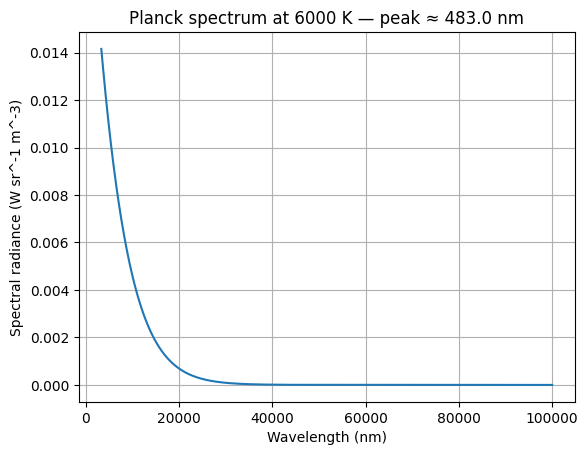

Integrated radiance (∫ B_lambda dλ): 2.294e+07 W sr^-1 m^-2
Power density per unit alpha (4*pi * ∫ B dλ): 2.883e+08 W m^-3 per (1/m) of alpha
Volume (cylinder r=5 mm, L=20 mm): 1.571e-06 m^3
alpha=1.000e+00  -> power density = 2.883e+08 W/m^3, total power = 4.529e+02 W
alpha=1.000e-01  -> power density = 2.883e+07 W/m^3, total power = 4.529e+01 W
alpha=1.000e-03  -> power density = 2.883e+05 W/m^3, total power = 4.529e-01 W

Stefan-Boltzmann constant: 5.670e-08 W m^-2 K^-4
Cylinder lateral area: 6.283e-04 m^2
Blackbody lateral surface power (sigma*T^4 * area): 4.617e+04 W


In [25]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.constants as const

# Temperature (K)
T = 6000.0
# Wavelength grid (m)
wavelengths = np.linspace(100e-9, 3000e-9, 2000)  # meters
wavenumbers_cm = 1 / wavelengths / 1e2 # m^-1
h, c, k = const.h, const.c, const.k

# Spectral radiance per unit wavelength: B_lambda (W sr^-1 m^-3)
B_lambda = (2*h*c**2) / (wavelengths**5) / (np.exp(h*c / (wavelengths*k*T)) - 1)
B_nu = (2*h*c**2 * wavenumbers_cm**3) / (np.exp(h*c*wavenumbers_cm * 1e2 / (k*T)) - 1)  # W sr^-1 m^-2

# Find peak (for plot title)
wavelengths_nm = wavelengths * 1e9
peak_idx = np.argmax(B_lambda)
peak_wavelength_nm = wavelengths_nm[peak_idx]

# Plot Planck spectrum
plt.plot(wavenumbers_cm, np.cumsum(B_nu))
# plt.plot(wavelengths_nm, np.cumsum(B_lambda))
plt.xlabel('Wavelength (nm)')
plt.ylabel('Spectral radiance (W sr^-1 m^-3)')
plt.title(f'Planck spectrum at {int(T)} K — peak ≈ {peak_wavelength_nm:.1f} nm')
# plt.yscale('log')
plt.grid(True)
plt.show()

# ----- Volumetric (optically thin) emission calculation -----
# We assume the emission coefficient j_lambda = alpha * B_lambda, where alpha (m^-1) is an
# effective absorption/emission coefficient. For optically thin media, the power emitted
# per unit volume (integrated over angles and wavelengths) is: P_vol = 4*pi*alpha *
#    which follows from integrating j_lambda over 4*pi steradians and all wavelengths.

# Numerically integrate B_lambda over wavelength to get ∫ B_lambda dλ (units: W sr^-1 m^-2)
integrated_B = np.trapezoid(B_lambda, wavelengths)
# integrated_B has units W sr^-1 m^-2. Multiplying by 4*pi gives W m^-2; multiply by alpha (m^-1) to get W m^-3.
power_density_per_alpha = 4 * np.pi * integrated_B  # this must be multiplied by alpha (m^-1) to get W m^-3

# Cylinder geometry (optically thin volume)
r = 5e-3  # radius in meters (5 mm)
L = 20e-3  # length in meters (20 mm)
volume = np.pi * r**2 * L

# Show results per unit absorption coefficient alpha, and for some example alpha values
alpha_examples = [1.0, 0.1, 1e-3]  # m^-1 (example scalings)
print(f'Integrated radiance (∫ B_lambda dλ): {integrated_B:.3e} W sr^-1 m^-2')
print(f'Power density per unit alpha (4*pi * ∫ B dλ): {power_density_per_alpha:.3e} W m^-3 per (1/m) of alpha')
print(f'Volume (cylinder r=5 mm, L=20 mm): {volume:.3e} m^3')

for alpha in alpha_examples:
    p_vol = alpha * power_density_per_alpha  # W m^-3
    total_power = p_vol * volume  # W
    print(f'alpha={alpha:.3e}  -> power density = {p_vol:.3e} W/m^3, total power = {total_power:.3e} W')

# For context: compare with the blackbody surface emission (Stefan-Boltzmann) of the cylinder lateral surface
sigma = const.Stefan_Boltzmann
lateral_area = 2 * np.pi * r * L
surface_power = sigma * T**4 * lateral_area
print('')
print(f'Stefan-Boltzmann constant: {sigma:.3e} W m^-2 K^-4')
print(f'Cylinder lateral area: {lateral_area:.3e} m^2')
print(f'Blackbody lateral surface power (sigma*T^4 * area): {surface_power:.3e} W')

# Note on assumptions: We did not specify a physical absorption coefficient alpha for the gas/plasma.
# The results above therefore show the emission per unit alpha; scale to your expected alpha to
# obtain an absolute emission number. If you prefer, set alpha to an estimated value for your
# medium and re-run the cell.


/var/folders/q9/b2jlk94n25n5w5bjvp02rsc00000gn/T/ipykernel_74444/1770369162.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  P_rad_total = np.trapz(P_rad_spectrum, nu_tilde_range)  # [W]


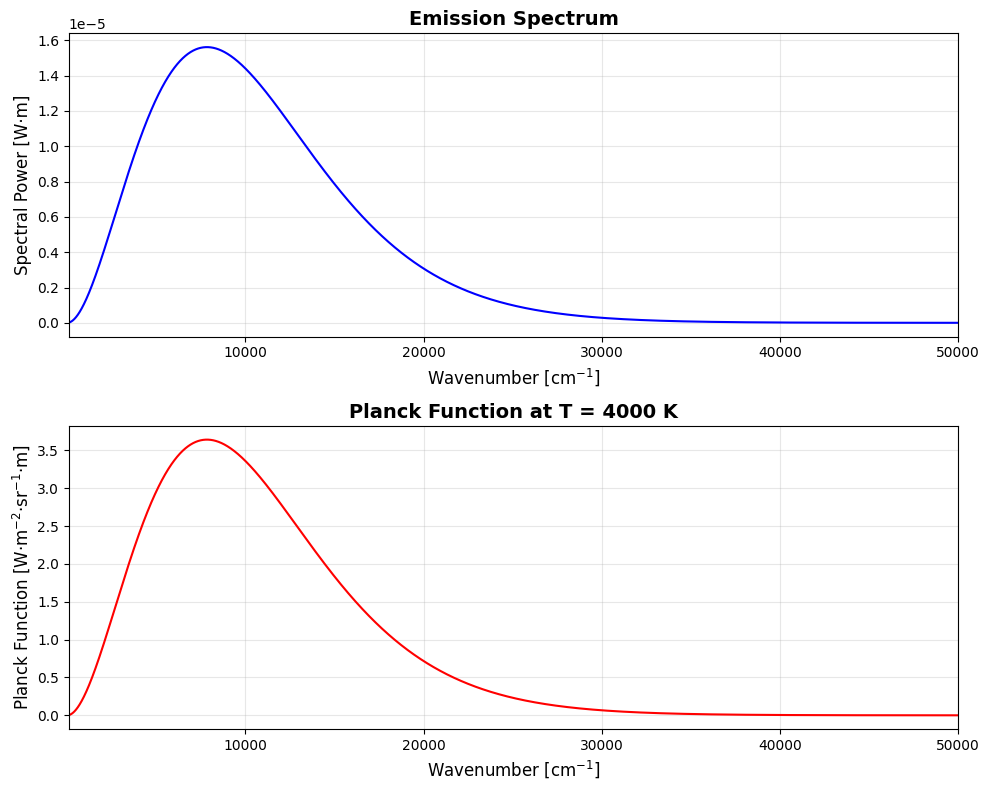

EMISSION CALCULATION RESULTS
Input Parameters:
  Pressure:     P = 1.20e+04 Pa
  Temperature:  T = 4000.0 K
  Volume:       V = 0.00 m³

Calculated Properties:
  Number density: n = 2.172e+23 m⁻³

Total Radiated Power:
  P_rad = 1.983e+01 W


In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
h = 6.626e-34  # Planck constant [J·s]
c = 2.998e8    # Speed of light [m/s]
k_B = 1.381e-23  # Boltzmann constant [J/K]
R = 8.314      # Gas constant [J/(mol·K)]

def planck_wavenumber(nu_tilde, T):
    """
    Planck function in terms of wavenumber
    
    Parameters:
    nu_tilde : array, wavenumber [m^-1]
    T : float, temperature [K]
    
    Returns:
    B : array, spectral radiance [W·m^-2·sr^-1·m]
    """
    exponent = h * c * nu_tilde / (k_B * T)
    # Avoid overflow for large exponents
    exponent = np.clip(exponent, None, 700)
    B = (2 * h * c**2 * nu_tilde**3) / (np.exp(exponent) - 1)
    return B

def emission_spectrum(P, T, V, sigma_func, nu_tilde_range):
    """
    Calculate emission spectrum for optically thin gas
    
    Parameters:
    P : float, pressure [Pa]
    T : float, temperature [K]
    V : float, volume [m^3]
    sigma_func : function, returns absorption cross-section [m^2] as function of wavenumber
    nu_tilde_range : array, wavenumber range [m^-1]
    
    Returns:
    P_rad_spectrum : array, spectral power [W·m]
    P_rad_total : float, total radiated power [W]
    """
    # Calculate number density from ideal gas law: P = n * k_B * T
    n = P / (k_B * T)  # [m^-3]
    
    # Get absorption cross-section values
    sigma = sigma_func(nu_tilde_range)  # [m^2]
    
    # Calculate Planck function
    B = planck_wavenumber(nu_tilde_range, T)  # [W·m^-2·sr^-1·m]
    
    # Calculate spectral emission
    P_rad_spectrum = 4 * np.pi * n * V * sigma * B  # [W·m]
    
    # Integrate to get total power using trapezoidal rule
    P_rad_total = np.trapz(P_rad_spectrum, nu_tilde_range)  # [W]
    
    return P_rad_spectrum, P_rad_total, n

# Example usage
if __name__ == "__main__":
    # Input parameters
    P = 120e2        # Pressure [Pa] (1 bar)
    T = 4000       # Temperature [K]
    V = np.pi*5e-3**2*20e-3        # Volume [m^3]
    
    # Define wavenumber range (e.g., 100 to 50000 cm^-1 = 1e4 to 5e6 m^-1)
    nu_tilde = np.linspace(1e4, 5e6, 10000)  # [m^-1]
    
    # Define absorption cross-section function (example: constant or wavelength-dependent)
    # Example 1: Constant cross-section
    def sigma_constant(nu_tilde):
        return 1e-20 * np.ones_like(nu_tilde) * 1e-2**2 # [m^2]
    
    # Example 2: Simple wavelength-dependent (decreasing with wavenumber)
    def sigma_varying(nu_tilde):
        # Simple model: sigma proportional to 1/nu_tilde
        return 1e-24 # [m^2]
    
    # Calculate emission spectrum
    P_spectrum, P_total, n = emission_spectrum(P, T, V, sigma_constant, nu_tilde)
    
    # Plot results
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    
    # Convert wavenumber to cm^-1 for plotting (common in spectroscopy)
    nu_tilde_cm = nu_tilde / 100  # [cm^-1]
    
    # Plot 1: Emission spectrum
    ax1.plot(nu_tilde_cm, P_spectrum, 'b-', linewidth=1.5)
    ax1.set_xlabel('Wavenumber [cm$^{-1}$]', fontsize=12)
    ax1.set_ylabel('Spectral Power [W·m]', fontsize=12)
    ax1.set_title('Emission Spectrum', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim([nu_tilde_cm[0], nu_tilde_cm[-1]])
    
    # Plot 2: Planck function for reference
    B = planck_wavenumber(nu_tilde, T)
    ax2.plot(nu_tilde_cm, B, 'r-', linewidth=1.5)
    ax2.set_xlabel('Wavenumber [cm$^{-1}$]', fontsize=12)
    ax2.set_ylabel('Planck Function [W·m$^{-2}$·sr$^{-1}$·m]', fontsize=12)
    ax2.set_title('Planck Function at T = {} K'.format(T), fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim([nu_tilde_cm[0], nu_tilde_cm[-1]])
    
    plt.tight_layout()
    plt.show()
    
    # Print results
    print("="*60)
    print("EMISSION CALCULATION RESULTS")
    print("="*60)
    print(f"Input Parameters:")
    print(f"  Pressure:     P = {P:.2e} Pa")
    print(f"  Temperature:  T = {T:.1f} K")
    print(f"  Volume:       V = {V:.2f} m³")
    print(f"\nCalculated Properties:")
    print(f"  Number density: n = {n:.3e} m⁻³")
    print(f"\nTotal Radiated Power:")
    print(f"  P_rad = {P_total:.3e} W")
    print("="*60)